In [1]:
from urllib.request import urlopen
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from collections import defaultdict

## Function that allows us to automate calls to the API so that we can extract data fro Large Data Sets ##


In [2]:
def get_blast_info(sn_name):
    """
    Fetch information for a supernova/transient from the BLAST API.

    Parameters
    ----------
    sn_name : str
        The supernova/transient name (e.g. "2004ef").

    Returns
    -------
    tuple
        (row_dict, missing_name_or_None)
        - On success: (dict of BLAST fields, None)
        - On failure: ({}, sn_name)
    """

    url = f"https://blast.ncsa.illinois.edu/api/transient/get/{sn_name}?format=json"
    try:
        with urlopen(url) as r:
            payload = json.loads(r.read())
    
    ## The following catches any Python Exception that happened within the "try" block.
    ## Error object gets stored as the variable e.
    ## Also keeps track of missing supernova names. Upon exceptions being thrown, ends up returning just
    ## the string that is the SNIa name. 
    except Exception as e:
        print(f"Error fetching {sn_name}: {e}")
        return {}, sn_name

    row = {
        "blast_transient_spectroscopic_class": (payload.get("transient_spectroscopic_class") or "").strip(),
        "blast_transient_photometric_class": (payload.get("transient_photometric_class") or "").strip(),
        
        "blast_host_name": payload.get("host_name"),
        "blast_host_ra_deg": payload.get("host_ra_deg"),
        "blast_host_dec_deg": payload.get("host_dec_deg"),
        "blast_host_redshift": payload.get("host_redshift"),
        "blast_host_EBV_MW": payload.get("host_milkyway_dust_reddening"),

        # Local SED
        "blast_local_log_mass_50": payload.get("local_aperture_host_log_mass_50"),
        "blast_local_log_sfr_50": payload.get("local_aperture_host_log_sfr_50"),
        "blast_local_log_ssfr_50": payload.get("local_aperture_host_log_ssfr_50"),
        "blast_local_log_age_50": payload.get("local_aperture_host_log_age_50"),
        "blast_local_mass_surviving_ratio": payload.get("local_aperture_host_mass_surviving_ratio"),

        # Global SED
        "blast_global_log_mass_50": payload.get("global_aperture_host_log_mass_50"),
        "blast_global_log_sfr_50": payload.get("global_aperture_host_log_sfr_50"),
        "blast_global_log_ssfr_50": payload.get("global_aperture_host_log_ssfr_50"),
        "blast_global_log_age_50": payload.get("global_aperture_host_log_age_50"),
        "blast_global_mass_surviving_ratio": payload.get("global_aperture_host_mass_surviving_ratio"),
    }
    return row, None

## Querying the DES Catalog ##

One of the biggest issues here is 

In [3]:
# Load your CSV 
csv_path = "data_P_S/Pantheon+SH0ES.csv"
df = pd.read_csv(csv_path)

# Collect BLAST info
blast_rows = []
missing_from_blast = []

# Can replace df["CID"] with whatever name df
# has for the IAUA name 
for sn in df["CID"]:
    row, missing = get_blast_info(str(sn))  # ensure string format
    blast_rows.append(row)
    if missing:   # missing is sn_name or None
        missing_from_blast.append(missing)

# Merge results back into DataFrame
blast_df = pd.DataFrame(blast_rows)
df = pd.concat([df, blast_df], axis=1)

# Save to new file
df.to_csv("data_P_S/Pantheon+SH0ES_BLAST_QUERY_v2.csv", index=False)

print("Failed lookups:", missing_from_blast)

Failed lookups: []


Now we will perform a quick sort that filters the .csv and splits it into what were were able to query from BLAST vs. what were wer not able to query from BLAST. 

In [4]:
# initial input .csv form the BLAST Query
csv_in  = "/Users/pittsburghgraduatestudent/repos/first_paper_blast_webapi/data_P_S/Pantheon+SH0ES_BLAST_QUERY_v2.csv"

# What we want to call the output files of matched and unmatched SNIa once all is said and done. 
csv_out = "/Users/pittsburghgraduatestudent/repos/first_paper_blast_webapi/data_P_S/Pantheon+SH0ES_BLAST_matches_v2.csv"
csv_missing = "/Users/pittsburghgraduatestudent/repos/first_paper_blast_webapi/data_P_S/Pantheon+SH0ES_BLAST_unmatched_v2.csv"

# Load
df = pd.read_csv(csv_in)

# All BLAST columns (those we added with the 'blast_' prefix)
blast_cols = [c for c in df.columns if c.startswith("blast_")]

# Mark rows that have at least ONE non-null BLAST value
has_blast = df[blast_cols].notna().any(axis=1)

# Keep only rows with BLAST info
kept = df[has_blast].copy()

# Rows removed = missing from BLAST entirely
missing = df[~has_blast].copy()

# Save results
kept.to_csv(csv_out, index=False)
missing.to_csv(csv_missing, index=False)

print(f"Kept {len(kept)} rows with BLAST data → {csv_out}")
print(f"Removed {len(missing)} rows missing BLAST data → {csv_missing}")

Kept 1615 rows with BLAST data → /Users/pittsburghgraduatestudent/repos/first_paper_blast_webapi/data_P_S/Pantheon+SH0ES_BLAST_matches_v2.csv
Removed 86 rows missing BLAST data → /Users/pittsburghgraduatestudent/repos/first_paper_blast_webapi/data_P_S/Pantheon+SH0ES_BLAST_unmatched_v2.csv


1701 P_S SNe Ia total
1615 matched with BLAST data


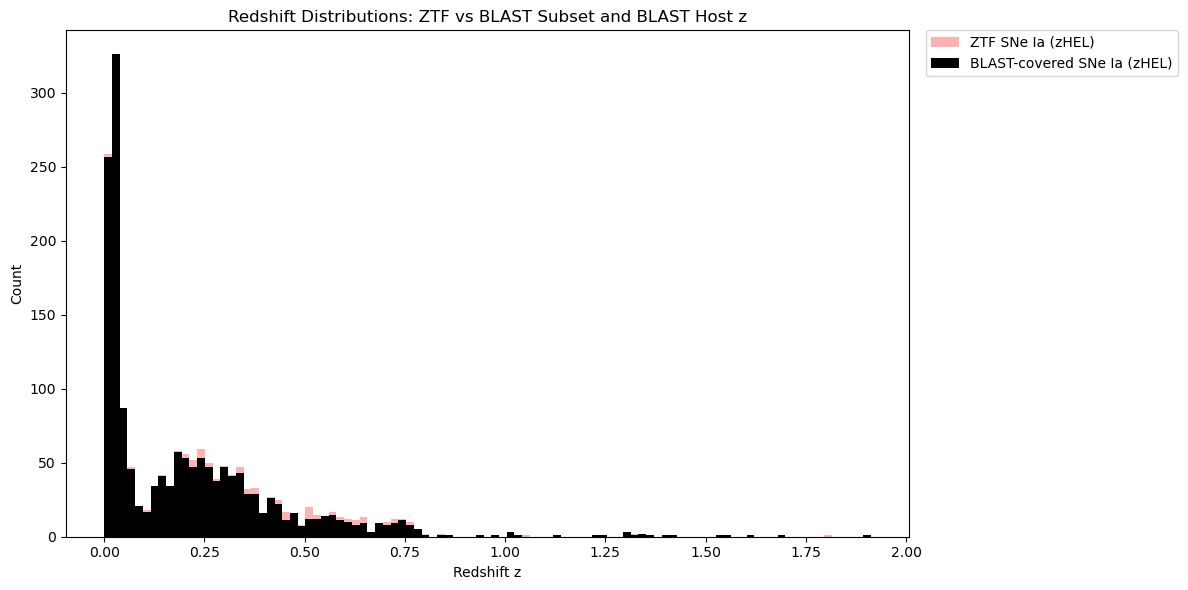

In [6]:
P_S_SN_CSV = "/Users/pittsburghgraduatestudent/repos/first_paper_blast_webapi/data_P_S/Pantheon+SH0ES.csv"
BLAST_P_S_CSV  = "/Users/pittsburghgraduatestudent/repos/first_paper_blast_webapi/data_P_S/Pantheon+SH0ES_BLAST_matches_v2.csv"

# Load
P_S_sn   = pd.read_csv(P_S_SN_CSV)
blast_df = pd.read_csv(BLAST_P_S_CSV)

print(len(P_S_sn), "P_S SNe Ia total")
matched = len(blast_df)
print(matched, "matched with BLAST data")

z_all_des      = pd.to_numeric(P_S_sn["zHD"])
z_blast_subset = pd.to_numeric(blast_df["zHD"])

# Shared binning — one line!
zmin = 0
zmax = z_blast_subset.max()
bins = np.linspace(zmin, zmax, 100)   # <-- control bins right here

plt.figure(figsize=(12, 6))
plt.hist(z_all_des,      bins=bins, alpha=0.3, label="ZTF SNe Ia (zHEL)", color = "red")
plt.hist(z_blast_subset, bins=bins, alpha=1, label="BLAST-covered SNe Ia (zHEL)", color = "black")

plt.xlabel("Redshift z")
plt.ylabel("Count")
plt.title("Redshift Distributions: ZTF vs BLAST Subset and BLAST Host z")
plt.legend(loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0)
plt.tight_layout()
plt.show()

1701 P_S SNe Ia total
1615 matched with BLAST data


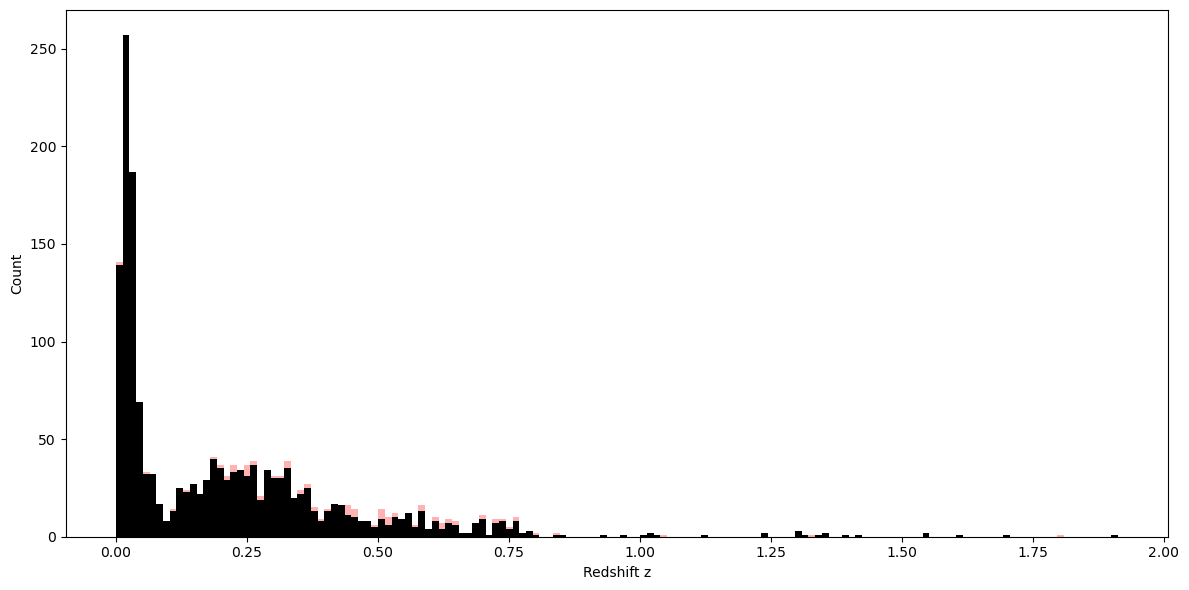

In [7]:
P_S_SN_CSV = "/Users/pittsburghgraduatestudent/repos/first_paper_blast_webapi/data_P_S/Pantheon+SH0ES.csv"
BLAST_CSV  = "/Users/pittsburghgraduatestudent/repos/first_paper_blast_webapi/data_P_S/Pantheon+SH0ES_BLAST_matches_v2.csv"

# Load
P_S_sn   = pd.read_csv(P_S_SN_CSV)
blast_df = pd.read_csv(BLAST_CSV)

print(len(P_S_sn), "P_S SNe Ia total")
matched = len(blast_df)
print(matched, "matched with BLAST data")

z_all_des      = pd.to_numeric(P_S_sn["zHD"])
z_blast_subset = pd.to_numeric(blast_df["zHD"])

# Shared binning — one line!
zmin = 0
zmax = z_blast_subset.max()
bins = np.linspace(zmin, zmax, 150)   # <-- control bins right here

plt.figure(figsize=(12, 6))
plt.hist(z_all_des,      bins=bins, alpha=0.3, label="P_S SNe Ia (zHD)", color = "red")
plt.hist(z_blast_subset, bins=bins, alpha=1, label="BLAST-covered SNe Ia (zHD)", color = "black")

plt.xlabel("Redshift z")
plt.ylabel("Count")
plt.tight_layout()
plt.show()